# 🔧 Python `itertools` — Complete Visual Notes
## From Beginner to Advanced (Fresher Edition)

---

> **`itertools`** is Python's built-in Swiss Army knife for working with iterators and sequences.
> It is fast, memory-efficient, and used daily by professional Python developers.

## 📚 Table of Contents

| # | Section | Level |
|---|---------|-------|
| 1 | Why `itertools`? Memory & Speed | 🟢 Beginner |
| 2 | Infinite Iterators — `count`, `cycle`, `repeat` | 🟢 Beginner |
| 3 | Chaining & Slicing — `chain`, `islice`, `zip_longest` | 🟢 Beginner |
| 4 | Filtering — `compress`, `filterfalse`, `takewhile`, `dropwhile` | 🟡 Intermediate |
| 5 | Grouping & Accumulating — `groupby`, `accumulate`, `pairwise` | 🟡 Intermediate |
| 6 | Mapping — `starmap` | 🟡 Intermediate |
| 7 | Combinatorics — `product`, `permutations`, `combinations` | 🟡 Intermediate |
| 8 | `tee` and `batched` | 🟡 Intermediate |
| 9 | **String Examples** — Deep Dive | 🟢🟡 |
| 10 | **List Examples** — Deep Dive | 🟢🟡 |
| 11 | **Dictionary Examples** — Deep Dive | 🟡 |
| 12 | **Nested List & Dict Examples** | 🟡🔴 |
| 13 | Combined with `operator`, `collections`, `functools` | 🔴 Advanced |
| 14 | Official Recipes (Hidden Gems) | 🔴 Advanced |
| 15 | Cheat Sheet | ⚡ Quick Ref |
| 16 | Practice Exercises | 📝 Test Yourself |

---
> **How to use:** Run every cell top to bottom. Each cell = ONE concept or example.

---
# Section 1: Why `itertools`? 🤔
---

## The Core Idea: Lazy Evaluation

Normal Python lists **create everything in memory at once**.
```python
my_list = [x * 2 for x in range(1_000_000)]  # Creates 1 million numbers RIGHT NOW in RAM
```

`itertools` functions are **lazy** — they produce values ONE AT A TIME only when you ask for them.
```python
import itertools
lazy = itertools.islice((x * 2 for x in range(1_000_000)), 5)  # Uses almost NO RAM
```

### Why does this matter?
- ✅ **Less Memory** — perfect for large files, big data
- ✅ **Faster** — no time wasted creating things you might not use
- ✅ **Cleaner Code** — replaces messy nested loops

In [16]:
import sys
import itertools

N = 100_000

list_version = [x * 2 for x in range(N)]   # Full list in RAM
iter_version = itertools.islice((x*2 for x in itertools.count()), N)  # Lazy

print(f'List version memory   : {sys.getsizeof(list_version):>10,} bytes')
print(f'Iterator memory       : {sys.getsizeof(iter_version):>10,} bytes')
print(f'\nList is {sys.getsizeof(list_version)//sys.getsizeof(iter_version)}x larger in memory!')

List version memory   :    800,984 bytes
Iterator memory       :         72 bytes

List is 11124x larger in memory!


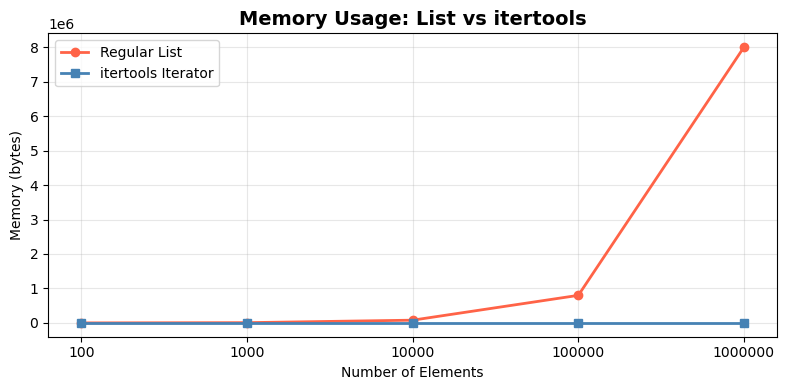

In [18]:
import matplotlib.pyplot as plt
import sys, itertools

sizes    = [100, 1_000, 10_000, 100_000, 1_000_000]
list_mem = [sys.getsizeof(list(range(n))) for n in sizes]
iter_mem = [sys.getsizeof(itertools.islice(itertools.count(), n)) for n in sizes]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([str(s) for s in sizes], list_mem, 'o-', color='tomato',   linewidth=2, label='Regular List')
ax.plot([str(s) for s in sizes], iter_mem, 's-', color='steelblue', linewidth=2, label='itertools Iterator')
ax.set_title('Memory Usage: List vs itertools', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Elements')
ax.set_ylabel('Memory (bytes)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Section 2: Infinite Iterators 🟢
## `count()`, `cycle()`, `repeat()`
---

> ⚠️ These run **forever** if you don't stop them! Always use with `islice()` or a `break`.

```
count(start, step) → 0, 1, 2, 3, 4  ... forever
cycle(seq)         → A, B, A, B, A  ... forever
repeat(val, n)     → x, x, x        ... n times
```

### `count(start, step)` — Count from a number forever (like an infinite range)

In [27]:
import itertools

# Auto-generate Employee IDs starting from 1001
id_generator = itertools.count(start=1001)
names        = ['Alice', 'Bob', 'Charlie']
employees    = list(zip(id_generator, names))

print('Employee IDs:', employees)

Employee IDs: [(1001, 'Alice'), (1002, 'Bob'), (1003, 'Charlie')]


In [28]:
import itertools

# Generate first 5 even numbers using count
even_counter  = itertools.count(start=0, step=2)
first_5_evens = list(itertools.islice(even_counter, 5))

print('First 5 even numbers:', first_5_evens)

First 5 even numbers: [0, 2, 4, 6, 8]


In [29]:
import itertools

# Countdown from 10 using negative step
countdown = list(itertools.islice(itertools.count(10, -1), 5))

print('Countdown:', countdown)

Countdown: [10, 9, 8, 7, 6]


### `cycle(seq)` — Loop through a sequence forever

In [30]:
import itertools

# Rotating weekday labels for a 14-day planner
days         = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
two_week_plan = list(itertools.islice(itertools.cycle(days), 14))

print('2-week schedule:', two_week_plan)

2-week schedule: ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']


In [31]:
import itertools

# Alternating row colors for a table (like a spreadsheet)
colors      = itertools.cycle(['white', 'lightgray'])
rows        = ['Row 1', 'Row 2', 'Row 3', 'Row 4', 'Row 5']
colored_rows = list(zip(rows, colors))

print('Table rows with alternating colors:')
for row, color in colored_rows:
    print(f'  {row:8} -> {color}')

Table rows with alternating colors:
  Row 1    -> white
  Row 2    -> lightgray
  Row 3    -> white
  Row 4    -> lightgray
  Row 5    -> white


In [32]:
import itertools

# Round-robin task assignment across 3 servers
servers     = itertools.cycle(['Server-A', 'Server-B', 'Server-C'])
tasks       = ['task1', 'task2', 'task3', 'task4', 'task5', 'task6']
assignments = list(zip(tasks, servers))

print('Round-robin task assignment:')
for task, server in assignments:
    print(f'  {task} → {server}')

Round-robin task assignment:
  task1 → Server-A
  task2 → Server-B
  task3 → Server-C
  task4 → Server-A
  task5 → Server-B
  task6 → Server-C


### `repeat(object, times)` — Repeat a value N times (or forever)

In [33]:
import itertools

# Provide a default department when zipping with a name list
names  = ['Alice', 'Bob', 'Charlie']
dept   = list(itertools.repeat('Engineering', 3))
result = list(zip(names, dept))

print('Name + Department:', result)

Name + Department: [('Alice', 'Engineering'), ('Bob', 'Engineering'), ('Charlie', 'Engineering')]


In [34]:
import itertools

# Square each number: map(pow, numbers, repeat(2)) gives exponent=2 each time
numbers = [2, 3, 4, 5, 6]
squares = list(map(pow, numbers, itertools.repeat(2)))

print('Numbers:', numbers)
print('Squares:', squares)

Numbers: [2, 3, 4, 5, 6]
Squares: [4, 9, 16, 25, 36]


In [35]:
import itertools

# Finite repeat — just repeat a value a fixed number of times
print('Repeat "hi" 4 times :', list(itertools.repeat('hi', 4)))
print('Repeat 0 three times:', list(itertools.repeat(0, 3)))

Repeat "hi" 4 times : ['hi', 'hi', 'hi', 'hi']
Repeat 0 three times: [0, 0, 0]


---
# Section 3: Chaining & Slicing 🟢
## `chain()`, `chain.from_iterable()`, `islice()`, `zip_longest()`
---

### `chain(*iterables)` — Combine multiple sequences into one, without creating a new list

In [36]:
import itertools

# Combine multiple shopping category lists into one
fruits  = ['apple', 'banana', 'cherry']
veggies = ['carrot', 'broccoli']
grains  = ['rice', 'wheat', 'oats']

all_items = list(itertools.chain(fruits, veggies, grains))
print('All groceries:', all_items)

All groceries: ['apple', 'banana', 'cherry', 'carrot', 'broccoli', 'rice', 'wheat', 'oats']


In [38]:
import itertools

# Chain strings — iterate character by character across multiple strings
greeting = ''.join(itertools.chain('Hello', ', ', 'World', '!'))
print('Chained strings:', greeting)

Chained strings: Hello, World!


In [39]:
import itertools

# Chain multiple ranges together
nums = list(itertools.chain(range(1, 4), range(10, 13), range(20, 23)))
print('Chained ranges:', nums)

Chained ranges: [1, 2, 3, 10, 11, 12, 20, 21, 22]


# ✅

### ✅`chain.from_iterable()` — Flatten a list of lists (one level deep)

In [42]:
import itertools

# Flatten a 2D nested list
nested = [[1, 2, 3], [4, 5], [6, 7, 8, 9]]
flat   = list(itertools.chain.from_iterable(nested))

print('Nested:', nested)
print('Flat  :', flat)

Nested: [[1, 2, 3], [4, 5], [6, 7, 8, 9]]
Flat  : [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [43]:
import itertools

# Collect all tags from multiple blog posts into a single list
posts = [
    {'title': 'Post 1', 'tags': ['python', 'coding']},
    {'title': 'Post 2', 'tags': ['django', 'web']},
    {'title': 'Post 3', 'tags': ['python', 'data']},
]

all_tags = list(itertools.chain.from_iterable(p['tags'] for p in posts))
print('All tags from all posts:', all_tags)

All tags from all posts: ['python', 'coding', 'django', 'web', 'python', 'data']


In [44]:
import itertools

# Flatten student grades from multiple classes, then calculate overall average
classes    = {'ClassA': [85, 90, 78], 'ClassB': [92, 88], 'ClassC': [76, 95, 80, 87]}
all_grades = list(itertools.chain.from_iterable(classes.values()))

print('All grades:', all_grades)
print('Overall average:', round(sum(all_grades) / len(all_grades), 2))

All grades: [85, 90, 78, 92, 88, 76, 95, 80, 87]
Overall average: 85.67


### `islice(iterable, start, stop, step)` — Slice any iterator without loading everything

In [45]:
import itertools

# Get first 5 items from an infinite generator
def endless_data():
    n = 0
    while True:
        yield f'item_{n}'
        n += 1

first_five = list(itertools.islice(endless_data(), 5))
print('First 5 items:', first_five)

First 5 items: ['item_0', 'item_1', 'item_2', 'item_3', 'item_4']


In [46]:
import itertools

# Pagination — get page 3 (items 20 to 29) from 100 results
all_products = [f'Product_{i}' for i in range(1, 101)]
page_num  = 3
per_page  = 10
start     = (page_num - 1) * per_page  # 20
stop      = page_num * per_page         # 30
page_data = list(itertools.islice(iter(all_products), start, stop))

print(f'Page {page_num} (items {start+1}-{stop}):', page_data)

Page 3 (items 21-30): ['Product_21', 'Product_22', 'Product_23', 'Product_24', 'Product_25', 'Product_26', 'Product_27', 'Product_28', 'Product_29', 'Product_30']


In [49]:
import itertools

# Skip first 3, then take every 2nd element up to position 15
data   = list(range(20))
result = list(itertools.islice(data, 3, 15, 2))

print('Original     :', data)
print('islice(3,15,2):', result)

Original     : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
islice(3,15,2): [3, 5, 7, 9, 11, 13]


### `zip_longest(*iterables, fillvalue)` — Zip lists of different lengths, filling missing values

In [52]:
import itertools

# Students and marks — lists have different lengths
students = ['Alice', 'Bob', 'Charlie', 'Diana']
marks    = [85, 92, 78]  # Diana didn't submit

paired = list(itertools.zip_longest(students, marks, fillvalue='ABSENT'))

print('Student Results:')
for name, mark in paired:
    print(f'  {name:10} → {mark}')

Student Results:
  Alice      → 85
  Bob        → 92
  Charlie    → 78
  Diana      → ABSENT


In [53]:
import itertools

# Combine 3 columns of unequal length into a table
col1 = ['a', 'b', 'c']
col2 = [1, 2, 3, 4, 5]
col3 = ['x', 'y']

table = list(itertools.zip_longest(col1, col2, col3, fillvalue='—'))
print('col1   col2   col3')
print('-' * 20)
for row in table:
    print('  '.join(str(v).ljust(6) for v in row))

col1   col2   col3
--------------------
a       1       x     
b       2       y     
c       3       —     
—       4       —     
—       5       —     


---
# Section 4: Filtering Iterators 🟡
## `compress()`, `filterfalse()`, `takewhile()`, `dropwhile()`
---

### `compress(data, selectors)` — Keep items where selector is True/1

In [54]:
import itertools

# Pick only ticked menu items (like checkboxes)
menu     = ['Burger', 'Pizza', 'Salad', 'Pasta', 'Soup']
selected = [1, 0, 1, 0, 1]   # 1 = selected, 0 = not selected

order = list(itertools.compress(menu, selected))
print('Selected items:', order)

Selected items: ['Burger', 'Salad', 'Soup']


In [55]:
import itertools

# Select only specific columns/keys from a record
keys   = ['name', 'age', 'email', 'address', 'phone']
wanted = [True, True, True, False, False]  # only name, age, email

chosen_keys = list(itertools.compress(keys, wanted))
print('Selected keys:', chosen_keys)

Selected keys: ['name', 'age', 'email']


In [56]:
import itertools

# Keep only students who submitted scores (score > 0 is truthy)
names  = ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank']
scores = [0, 85, 0, 92, 78, 0]  # 0 = not submitted

present = list(itertools.compress(names, scores))  # 0 is falsy, non-zero is truthy
print('Students who submitted:', present)

Students who submitted: ['Bob', 'Diana', 'Eve']


### `filterfalse(func, iterable)` — Keep items where the function returns FALSE (opposite of filter)

In [57]:
import itertools

# Keep only ODD numbers (filter out even ones)
nums = range(1, 11)
odds = list(itertools.filterfalse(lambda x: x % 2 == 0, nums))

print('Odd numbers:', odds)

Odd numbers: [1, 3, 5, 7, 9]


In [58]:
import itertools

# Keep only incomplete/pending tasks
tasks = [
    {'name': 'Write report',  'done': True},
    {'name': 'Send email',    'done': False},
    {'name': 'Fix bug',       'done': False},
    {'name': 'Review PR',     'done': True},
]

incomplete = list(itertools.filterfalse(lambda t: t['done'], tasks))
print('Incomplete tasks:')
for t in incomplete:
    print(f'  ☐ {t["name"]}')

Incomplete tasks:
  ☐ Send email
  ☐ Fix bug


In [59]:
import itertools

# Remove None and empty strings from a list
data  = ['Alice', None, 'Bob', '', 'Charlie', None, 'Diana']
clean = list(itertools.filterfalse(lambda x: not x, data))

print('Original:', data)
print('Cleaned :', clean)

Original: ['Alice', None, 'Bob', '', 'Charlie', None, 'Diana']
Cleaned : ['Alice', 'Bob', 'Charlie', 'Diana']


### `takewhile(condition, iterable)` — Take elements WHILE condition is True, stop the moment it becomes False

In [60]:
import itertools

# Read log entries until an ERROR appears
logs = ['INFO start', 'INFO loading', 'INFO connected', 'ERROR timeout', 'INFO retry']

before_error = list(itertools.takewhile(lambda x: not x.startswith('ERROR'), logs))
print('Logs before first error:', before_error)

Logs before first error: ['INFO start', 'INFO loading', 'INFO connected']


In [ ]:
import itertools

# Take temperature readings while they are in the safe range (< 50°C)
temperatures = [22, 25, 30, 45, 51, 60, 72]  # sorted ascending

safe_temps = list(itertools.takewhile(lambda t: t < 50, temperatures))
print('All temperatures:', temperatures)
print('Safe range (< 50):', safe_temps)

### `dropwhile(condition, iterable)` — Skip elements WHILE condition is True, then take everything after

In [ ]:
import itertools

# Skip leading zeros in sensor readings (zeros = calibration period)
sensor   = [0, 0, 0, 3, 7, 2, 0, 5]
readings = list(itertools.dropwhile(lambda x: x == 0, sensor))

print('Raw sensor data  :', sensor)
print('Actual readings  :', readings)

In [ ]:
import itertools

# Skip comment lines at the top of a data file
raw_data    = ['# Comment line', '# Author: John', 'Alice,25', 'Bob,30', 'Charlie,22']
actual_data = list(itertools.dropwhile(lambda x: x.startswith('#'), raw_data))

print('All lines    :', raw_data)
print('Data only    :', actual_data)

---
# Section 5: Grouping & Accumulating 🟡
## `groupby()`, `accumulate()`, `pairwise()`
---

# ✅

### `groupby()` — The #1 Most Important Rule ⚠️

> **ALWAYS sort your data by the group key BEFORE using `groupby()`!**
> `groupby()` only groups **consecutive** identical elements.

```python
# ❌ WRONG — data not sorted, will create duplicate groups
for key, group in itertools.groupby(data, key=...): ...

# ✅ CORRECT — sort first!
for key, group in itertools.groupby(sorted(data, key=keyfunc), key=keyfunc): ...
```

In [62]:
import itertools

# Group employees by department
employees = [
    {'name': 'Alice',   'dept': 'Engineering'},
    {'name': 'Bob',     'dept': 'Marketing'},
    {'name': 'Charlie', 'dept': 'Engineering'},
    {'name': 'Diana',   'dept': 'HR'},
    {'name': 'Eve',     'dept': 'Marketing'},
]

# STEP 1: Sort first!
sorted_emp = sorted(employees, key=lambda e: e['dept'])

# STEP 2: Group
print('Employees by Department:')
for dept, group in itertools.groupby(sorted_emp, key=lambda e: e['dept']):
    names = [e['name'] for e in group]
    print(f'  {dept}: {names}')

Employees by Department:
  Engineering: ['Alice', 'Charlie']
  HR: ['Diana']
  Marketing: ['Bob', 'Eve']


In [63]:
import itertools

# Group characters in a string — Run-Length Encoding
# (This is how data compression works!)
text = 'aaabbbccddddee'

encoded = [(char, len(list(group))) for char, group in itertools.groupby(text)]
print(f'Original : "{text}"')
print(f'Encoded  : {encoded}')

# Decode back
decoded = ''.join(char * count for char, count in encoded)
print(f'Decoded  : "{decoded}"')

Original : "aaabbbccddddee"
Encoded  : [('a', 3), ('b', 3), ('c', 2), ('d', 4), ('e', 2)]
Decoded  : "aaabbbccddddee"


In [66]:
import itertools

# Group numbers as Even or Odd
numbers = [1, 4, 7, 2, 8, 3, 6, 9, 5]
sorted_nums = sorted(numbers, key=lambda x: x % 2)  # 0=even first, 1=odd second

print('Numbers grouped by Even/Odd:')
for key, grp in itertools.groupby(sorted_nums, key=lambda x: x % 2):
    label = 'ODD' if key else 'EVEN'
    print(f'  {label}: {list(grp)}')

Numbers grouped by Even/Odd:
  EVEN: [4, 2, 8, 6]
  ODD: [1, 7, 3, 9, 5]


### `accumulate(iterable, func)` — Running calculations (keeps all intermediate results)

In [67]:
import itertools

# Running total of daily sales
daily_sales = [200, 350, 150, 400, 300, 250]
cumulative  = list(itertools.accumulate(daily_sales))

print('Daily sales  :', daily_sales)
print('Running total:', cumulative)

Daily sales  : [200, 350, 150, 400, 300, 250]
Running total: [200, 550, 700, 1100, 1400, 1650]


In [69]:
import itertools

# Running maximum — track high score as it updates
scores      = [45, 80, 60, 95, 70, 100, 88]
high_scores = list(itertools.accumulate(scores, max))

print('Scores          :', scores)
print('Running high score:', high_scores)

Scores          : [45, 80, 60, 95, 70, 100, 88]
Running high score: [45, 80, 80, 95, 95, 100, 100]


In [70]:
import itertools, operator

# Running product using operator.mul — generates factorial sequence
nums       = [1, 2, 3, 4, 5]
factorials = list(itertools.accumulate(nums, operator.mul))

print('Numbers   :', nums)
print('Factorials:', factorials)  # 1, 2, 6, 24, 120

Numbers   : [1, 2, 3, 4, 5]
Factorials: [1, 2, 6, 24, 120]


In [71]:
import itertools

# accumulate with an initial starting value (Python 3.8+)
monthly = [1000, 2000, 1500]
result  = list(itertools.accumulate(monthly, initial=5000))  # start from 5000

print('Monthly additions:', monthly)
print('Running total (starting at 5000):', result)

Monthly additions: [1000, 2000, 1500]
Running total (starting at 5000): [5000, 6000, 8000, 9500]


### `pairwise()` — Consecutive overlapping pairs: (a,b), (b,c), (c,d)... (Python 3.10+)

In [72]:
import itertools, sys

# Setup: use itertools.pairwise if available, else make our own
if hasattr(itertools, 'pairwise'):
    pairwise = itertools.pairwise
    print('Using itertools.pairwise (Python 3.10+)')
else:
    def pairwise(iterable):
        a, b = itertools.tee(iterable)
        next(b, None)
        return zip(a, b)
    print('Using manual pairwise (Python < 3.10)')

Using itertools.pairwise (Python 3.10+)


In [73]:
# Calculate day-to-day temperature changes
temps   = [22, 25, 19, 30, 28, 35]
changes = [b - a for a, b in pairwise(temps)]

print('Temperatures  :', temps)
print('Daily changes :', changes)

Temperatures  : [22, 25, 19, 30, 28, 35]
Daily changes : [3, -6, 11, -2, 7]


In [74]:
# Create bigrams from a sentence (used in NLP / autocomplete)
sentence = 'the cat sat on mat'
words    = sentence.split()
bigrams  = list(pairwise(words))

print('Sentence :', sentence)
print('Bigrams  :', bigrams)

Sentence : the cat sat on mat
Bigrams  : [('the', 'cat'), ('cat', 'sat'), ('sat', 'on'), ('on', 'mat')]


---
# Section 6: Mapping — `starmap()` 🟡
---

### `starmap(func, iterable_of_tuples)` — Like `map()` but automatically UNPACKS each tuple as separate arguments

```python
# map() needs you to unpack manually:
result = [pow(base, exp) for base, exp in pairs]

# starmap() does it automatically:
result = list(itertools.starmap(pow, pairs))
```

In [ ]:
import itertools

# Calculate powers: (base, exponent) pairs
pairs  = [(2, 3), (4, 2), (5, 3), (10, 2)]
result = list(itertools.starmap(pow, pairs))

print('Pairs (base, exp):', pairs)
print('Results           :', result)

In [ ]:
import itertools, operator

# Multiply price × quantity for each product
prices     = {'apple': 1.5, 'banana': 0.75, 'cherry': 2.0}
quantities = {'apple': 3,   'banana': 5,     'cherry': 2}

pairs  = [(prices[k], quantities[k]) for k in prices]
totals = list(itertools.starmap(operator.mul, pairs))

print('Item totals (price × qty):')
for item, total in zip(prices.keys(), totals):
    print(f'  {item:8}: ₹{total:.2f}')

In [ ]:
import itertools

# Apply (x_offset, y_offset) to a base position using a lambda
base_x, base_y = 10, 20
offsets        = [(1, 2), (3, -1), (-2, 5), (0, 3)]

positions = list(itertools.starmap(lambda dx, dy: (base_x+dx, base_y+dy), offsets))
print('Offsets  :', offsets)
print('Positions:', positions)

---
# Section 7: Combinatorics 🟡
## `product()`, `permutations()`, `combinations()`, `combinations_with_replacement()`
---

```
product(A, B)                         → All pairs from A × B (like nested for loops)
permutations(A, r)                    → All ORDERED arrangements of r items
combinations(A, r)                    → All UNORDERED selections of r items
combinations_with_replacement(A, r)   → Unordered, but same item CAN repeat
```

### `product(*iterables, repeat=1)` — Cartesian product (replaces nested for-loops)

In [ ]:
import itertools

# All T-shirt variants: size × color × style
sizes  = ['S', 'M', 'L']
colors = ['Red', 'Blue']
styles = ['Cotton', 'Polyester']

combos = list(itertools.product(sizes, colors, styles))
print(f'Total variants: {len(combos)}')
for c in combos:
    print(f'  Size:{c[0]}, Color:{c[1]}, Material:{c[2]}')

In [ ]:
import itertools

# All possible outcomes of rolling two 6-sided dice
dice   = range(1, 7)
rolls  = list(itertools.product(dice, repeat=2))  # dice × dice
totals = [a + b for a, b in rolls]

# Count frequency of each sum
freq = {t: totals.count(t) for t in sorted(set(totals))}
print('Dice sum frequency (█ = 1 occurrence):')
for total, count in freq.items():
    bar = '█' * count
    print(f'  Sum {total:2d}: {bar} ({count})')

In [ ]:
import itertools

# Generate all 3-bit binary strings using product
binary_strings = [''.join(b) for b in itertools.product('01', repeat=3)]
print('All 3-bit binary strings:', binary_strings)

### `permutations(iterable, r)` — All ORDERED arrangements

In [ ]:
import itertools

# All possible podium finishes for 3 runners
runners = ['Alice', 'Bob', 'Charlie']
podiums = list(itertools.permutations(runners))

print(f'Possible finishes: {len(podiums)}')
for pos in podiums:
    print(f'  🥇{pos[0]}, 🥈{pos[1]}, 🥉{pos[2]}')

In [ ]:
import itertools

# All 2-letter codes from A, B, C, D (for PIN/code generation)
codes = [''.join(c) for c in itertools.permutations('ABCD', 2)]

print(f'All 2-letter codes ({len(codes)} total):', codes)

In [ ]:
import itertools

# Generate all anagrams of a word
word     = 'CAT'
anagrams = sorted(set(''.join(p) for p in itertools.permutations(word)))

print(f'Anagrams of {word!r}: {anagrams}')

### `combinations(iterable, r)` — All UNORDERED subsets (no repetition)

In [ ]:
import itertools

# Choose 2 players from 4 for a doubles tennis team
players = ['Alice', 'Bob', 'Charlie', 'Diana']
teams   = list(itertools.combinations(players, 2))

print(f'All possible doubles teams ({len(teams)} total):')
for team in teams:
    print(f'  {team[0]} & {team[1]}')

In [ ]:
import itertools

# Generate all football match fixtures (each pair plays once)
teams    = ['Team_A', 'Team_B', 'Team_C', 'Team_D']
fixtures = list(itertools.combinations(teams, 2))

print(f'Match fixtures ({len(fixtures)} matches):')
for i, (home, away) in enumerate(fixtures, 1):
    print(f'  Match {i}: {home} vs {away}')

In [ ]:
import itertools

# Choose 3 dishes from a menu for a 3-course meal
dishes = ['Soup', 'Salad', 'Steak', 'Fish', 'Cake']
meals  = list(itertools.combinations(dishes, 3))

print(f'Possible 3-course meals: {len(meals)}')
for meal in meals[:5]:
    print(' ', meal)

### `combinations_with_replacement(iterable, r)` — Subsets where same item CAN repeat

In [ ]:
import itertools

# Ice cream: choose 2 scoops, same flavor allowed
flavors = ['Choc', 'Vanilla', 'Strawberry']
scoops  = list(itertools.combinations_with_replacement(flavors, 2))

print(f'2-scoop combinations with repeats ({len(scoops)} total):')
for s in scoops:
    print(f'  {s[0]} + {s[1]}')

In [ ]:
import itertools

# All dice outcomes when order doesn't matter and repeats are allowed
dice    = [1, 2, 3, 4, 5, 6]
results = list(itertools.combinations_with_replacement(dice, 2))

print(f'Unique dice pairs (order ignored, repeats OK): {len(results)}')
# Compare: product gives 36, combinations_with_replacement gives 21
print('Compare: product gives', len(list(itertools.product(dice, repeat=2))), 'outcomes')

---
# Section 8: `tee()` and `batched()` 🟡
---

### `tee(iterable, n=2)` — Split one iterator into n independent copies

In [ ]:
import itertools

# Process the same data in two different ways without re-reading
data = iter([10, 20, 30, 40, 50])
iter1, iter2 = itertools.tee(data, 2)

divisible_by_20 = [x for x in iter1 if x % 20 == 0]
greater_than_25 = [x for x in iter2 if x > 25]

print('Divisible by 20:', divisible_by_20)
print('Greater than 25:', greater_than_25)

In [ ]:
import itertools

# Track stock price changes using two tee'd iterators
def day_changes(prices):
    a, b = itertools.tee(prices)
    next(b, None)   # shift second iterator forward by 1
    return [round(y - x, 2) for x, y in zip(a, b)]

stock_prices = [100, 105, 98, 112, 108, 115]
changes      = day_changes(iter(stock_prices))

print('Stock prices:', stock_prices)
print('Daily change:', changes)

### `batched(iterable, n)` — Split into chunks of size n (Python 3.12+, manual fallback included)

In [ ]:
import itertools, sys

print(f'Python version: {sys.version[:6]}')

# batched — send API requests in batches of 5
users = list(range(1, 23))  # 22 users

try:
    batches = list(itertools.batched(users, 5))
except AttributeError:
    # Manual fallback for Python < 3.12
    def batched(iterable, n):
        it = iter(iterable)
        while chunk := list(itertools.islice(it, n)):
            yield chunk
    batches = list(batched(users, 5))

print('Users split into groups of 5:')
for i, batch in enumerate(batches, 1):
    print(f'  Batch {i}: {list(batch)}')

---
# Section 9: Deep Dive — Strings with `itertools` 🟢🟡
---

In [ ]:
import itertools

# chain — merge multiple strings without creating a new big string in RAM
first  = 'Hello'
middle = ', Beautiful'
last   = ' World!'

merged = ''.join(itertools.chain(first, middle, last))
print('chain strings:', merged)

In [ ]:
import itertools

# islice — get first N characters (like a preview/truncate)
long_text = 'Python is an amazing programming language for absolute beginners'
preview   = ''.join(itertools.islice(long_text, 25)) + '...'

print('Full text:', long_text)
print('Preview  :', preview)

In [ ]:
import itertools

# cycle — create a repeating pattern string
pattern = ''.join(itertools.islice(itertools.cycle('-=*'), 24))
print('Repeating pattern:', pattern)

In [ ]:
import itertools

# compress — pick specific characters from a string using a boolean mask
word = 'PROGRAMMING'
mask = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]  # pick every other char

filtered = ''.join(itertools.compress(word, mask))
print(f'Original : {word}')
print(f'Mask     : {mask}')
print(f'Filtered : {filtered}')

In [ ]:
import itertools

# groupby on a string — Run-Length Encoding (how ZIP compression works!)
text    = 'aaaaabbbccdddddee'
encoded = [(char, len(list(group))) for char, group in itertools.groupby(text)]
decoded = ''.join(char * count for char, count in encoded)

print(f'Original : "{text}"')
print(f'Encoded  : {encoded}')
print(f'Decoded  : "{decoded}"')

In [ ]:
import itertools

# pairwise — generate bigrams (used in NLP / autocomplete systems)
sentence = 'I love Python programming'
words    = sentence.split()

try:
    bigrams = list(itertools.pairwise(words))
except AttributeError:
    a, b = itertools.tee(words)
    next(b)
    bigrams = list(zip(a, b))

print('Sentence:', sentence)
print('Bigrams :', bigrams)

In [ ]:
import itertools

# permutations — generate all anagrams of a word
word     = 'EAT'
anagrams = sorted(set(''.join(p) for p in itertools.permutations(word)))

print(f'All anagrams of "{word}": {anagrams}')

In [ ]:
import itertools

# combinations — all possible 2-letter selections from a word
text  = 'ABCD'
pairs = [''.join(c) for c in itertools.combinations(text, 2)]

print(f'All 2-char combos from "{text}": {pairs}')

---
# Section 10: Deep Dive — Lists with `itertools` 🟢🟡
---

In [ ]:
import itertools

# chain — merge multiple lists in one pass (no new list created!)
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list3 = [7, 8, 9]

merged = list(itertools.chain(list1, list2, list3))
print('Merged lists:', merged)

In [ ]:
import itertools

# chain.from_iterable — flatten a list of lists
nested = [[10, 20], [30, 40, 50], [60]]
flat   = list(itertools.chain.from_iterable(nested))

print('Nested :', nested)
print('Flat   :', flat)

In [ ]:
import itertools

# accumulate — running high score tracker in a game
game_scores = [45, 30, 80, 55, 95, 40, 70]
running_max = list(itertools.accumulate(game_scores, max))

print('Game scores  :', game_scores)
print('High score   :', running_max)

In [ ]:
import itertools

# compress — pick only in-stock products using a boolean mask
products = ['Laptop', 'Phone', 'Tablet', 'Watch', 'Earbuds']
in_stock = [True, False, True, True, False]

available = list(itertools.compress(products, in_stock))
print('In-stock items:', available)

In [ ]:
import itertools

# islice — pagination: show page 3 out of 50 results
all_results = [f'Result_{i}' for i in range(1, 51)]
page_num    = 3
per_page    = 10
start       = (page_num - 1) * per_page   # 20
stop        = page_num * per_page          # 30

page_data = list(itertools.islice(all_results, start, stop))
print(f'Page {page_num} results:', page_data)

In [ ]:
import itertools

# takewhile — keep only passing scores (sorted descending)
scores  = sorted([92, 88, 75, 68, 55, 42, 30], reverse=True)
passing = list(itertools.takewhile(lambda x: x >= 60, scores))

print('All scores (sorted):', scores)
print('Passing (>= 60)    :', passing)

In [ ]:
import itertools

# product — generate all t-shirt variants (size × color)
sizes        = ['S', 'M', 'L', 'XL']
colors       = ['Red', 'Blue', 'Green']
all_variants = list(itertools.product(sizes, colors))

print(f'Total variants: {len(all_variants)}')
for v in all_variants:
    print(f'  {v[0]} - {v[1]}')

In [ ]:
import itertools

# zip_longest — merge quiz questions and student answers of different lengths
questions = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
answers   = ['A', 'B', 'D']

quiz = list(itertools.zip_longest(questions, answers, fillvalue='NOT ANSWERED'))
print('Quiz results:')
for q, a in quiz:
    print(f'  {q}: {a}')

---
# Section 11: Deep Dive — Dictionaries with `itertools` 🟡
---

In [ ]:
import itertools

# chain on dict.items() — merge multiple dicts into one
config1 = {'host': 'localhost', 'port': 5432}
config2 = {'user': 'admin',     'password': 'secret'}
config3 = {'db': 'mydb',        'timeout': 30}

merged_dict = dict(itertools.chain(config1.items(), config2.items(), config3.items()))
print('Merged config dict:', merged_dict)

In [ ]:
import itertools

# compress on dict keys — select only the wanted keys from a record
full_record = {'name': 'Alice', 'age': 25, 'email': 'alice@test.com',
               'salary': 70000, 'address': 'Delhi', 'phone': '9999'}
all_keys    = list(full_record.keys())
mask        = [True, True, True, False, False, False]  # only name, age, email

selected    = {k: full_record[k] for k in itertools.compress(all_keys, mask)}
print('Public profile:', selected)

In [ ]:
import itertools

# starmap on dict.items() — apply a function to every key-value pair
product_prices = {'apple': 1.5, 'banana': 0.75, 'cherry': 2.0, 'mango': 3.5}
tax_rate       = 0.18

after_tax = dict(itertools.starmap(
    lambda k, v: (k, round(v * (1 + tax_rate), 2)),
    product_prices.items()
))
print('Prices after 18% GST:', after_tax)

In [ ]:
import itertools

# accumulate on dict values — running monthly sales total
monthly_sales = {'Jan': 5000, 'Feb': 7200, 'Mar': 6800, 'Apr': 9100, 'May': 8500}

cumulative = dict(zip(
    monthly_sales.keys(),
    itertools.accumulate(monthly_sales.values())
))
print('Cumulative Sales:')
for month, total in cumulative.items():
    print(f'  {month}: ₹{total:,}')

In [ ]:
import itertools

# filterfalse on dict items — remove entries with zero or None value
inventory = {'apple': 50, 'banana': 0, 'cherry': 30, 'mango': None, 'grape': 25}

in_stock = dict(itertools.filterfalse(
    lambda item: not item[1],   # filter out falsy values (0, None)
    inventory.items()
))
print('Original inventory:', inventory)
print('In-stock only      :', in_stock)

In [ ]:
import itertools

# groupby on list-of-dicts — group orders by status
orders = [
    {'id': 1, 'status': 'delivered', 'amount': 500},
    {'id': 2, 'status': 'pending',   'amount': 300},
    {'id': 3, 'status': 'delivered', 'amount': 750},
    {'id': 4, 'status': 'cancelled', 'amount': 200},
    {'id': 5, 'status': 'pending',   'amount': 450},
    {'id': 6, 'status': 'delivered', 'amount': 620},
]

sorted_orders = sorted(orders, key=lambda o: o['status'])
print('Orders by Status:')
for status, group in itertools.groupby(sorted_orders, key=lambda o: o['status']):
    items = list(group)
    total = sum(o['amount'] for o in items)
    print(f'  {status.upper():12} | {len(items)} orders | Total: ₹{total}')

---
# Section 12: Deep Dive — Nested Lists & Dicts 🟡🔴
---

In [ ]:
import itertools

# chain.from_iterable — flatten a 2D matrix into a flat list
matrix = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
flat   = list(itertools.chain.from_iterable(matrix))

print('Matrix    :', matrix)
print('Flattened :', flat)

In [ ]:
import itertools

# Deep flatten a 3-level nested list using recursion + yield
deep_nested = [[1, [2, 3]], [4, 5], [[6, [7, 8]]]]

def deep_flatten(lst):
    for item in lst:
        if isinstance(item, list):
            yield from deep_flatten(item)
        else:
            yield item

print('Deep nested :', deep_nested)
print('Flattened   :', list(deep_flatten(deep_nested)))

In [ ]:
import itertools

# product on nested categories — generate all product variants
catalog = [
    ['S', 'M', 'L'],        # Sizes
    ['Red', 'Blue'],         # Colors
    ['Cotton', 'Polyester']  # Materials
]

all_combos = list(itertools.product(*catalog))  # * unpacks the list of lists
print(f'All product combinations: {len(all_combos)}')
for c in all_combos:
    print(f'  Size:{c[0]}, Color:{c[1]}, Material:{c[2]}')

In [ ]:
import itertools
from collections import Counter

# Flatten tags from multiple posts and count frequency
tag_lists = [['python', 'coding'], ['web', 'python'], ['data', 'coding', 'python']]
all_tags  = list(itertools.chain.from_iterable(tag_lists))
tag_count = Counter(all_tags)

print('All tags :', all_tags)
print('Frequency:', dict(tag_count.most_common()))

In [ ]:
import itertools

# groupby on list of nested dicts — group students by grade
students = [
    {'name': 'Alice',   'grade': 'A', 'score': 92},
    {'name': 'Bob',     'grade': 'B', 'score': 78},
    {'name': 'Charlie', 'grade': 'A', 'score': 88},
    {'name': 'Diana',   'grade': 'C', 'score': 65},
    {'name': 'Eve',     'grade': 'B', 'score': 82},
    {'name': 'Frank',   'grade': 'A', 'score': 95},
]

by_grade = sorted(students, key=lambda s: s['grade'])
print('Students grouped by Grade:')
for grade, grp in itertools.groupby(by_grade, key=lambda s: s['grade']):
    members = list(grp)
    names   = [s['name'] for s in members]
    avg     = sum(s['score'] for s in members) / len(members)
    print(f'  Grade {grade}: {names} | Avg: {avg:.1f}')

In [ ]:
import itertools

# chain across nested dict values — collect all salaries company-wide
company = {
    'Engineering': {'Alice': 90000, 'Charlie': 85000, 'Frank': 95000},
    'Marketing'  : {'Bob': 75000, 'Eve': 80000},
    'HR'         : {'Diana': 70000},
}

all_salaries = list(itertools.chain.from_iterable(dept.values() for dept in company.values()))
print('All salaries:', all_salaries)
print(f'Total employees: {len(all_salaries)}')
print(f'Average salary : ₹{sum(all_salaries)//len(all_salaries):,}')

In [ ]:
import itertools

# chain nested dict items — get a flat dict of all employees from all departments
company = {
    'Engineering': {'Alice': 90000, 'Charlie': 85000},
    'Marketing'  : {'Bob': 75000, 'Eve': 80000},
    'HR'         : {'Diana': 70000},
}

all_employees = dict(itertools.chain.from_iterable(dept.items() for dept in company.values()))
print('All employees flat dict:')
for name, salary in all_employees.items():
    print(f'  {name:10}: ₹{salary:,}')

---
# Section 13: `itertools` + Other Tools 🔴
## `operator`, `collections`, `functools`
---

In [ ]:
import itertools, operator

# itertools + operator.mul — generate factorial sequence with accumulate
nums       = [1, 2, 3, 4, 5, 6]
factorials = list(itertools.accumulate(nums, operator.mul))

print('Numbers   :', nums)
print('Factorials:', factorials)

In [ ]:
import itertools, operator

# itertools + operator — division and modulo using starmap
pairs = [(10, 3), (15, 4), (7, 2)]

divs  = [round(d, 2) for d in itertools.starmap(operator.truediv, pairs)]
mods  = list(itertools.starmap(operator.mod, pairs))

print('Pairs     :', pairs)
print('Divisions :', divs)
print('Modulos   :', mods)

In [ ]:
import itertools, operator

# itertools + operator.itemgetter — groupby without lambda (cleaner!)
data = [
    {'city': 'Delhi',  'temp': 38},
    {'city': 'Mumbai', 'temp': 32},
    {'city': 'Delhi',  'temp': 40},
    {'city': 'Mumbai', 'temp': 30},
]

sorted_data = sorted(data, key=operator.itemgetter('city'))
print('Average temperature by city:')
for city, grp in itertools.groupby(sorted_data, key=operator.itemgetter('city')):
    temps = [d['temp'] for d in grp]
    print(f'  {city}: {sum(temps)/len(temps):.1f}°C')

In [ ]:
import itertools
from collections import Counter

# itertools + Counter — word frequency across multiple sentences
sentences = ['I love python', 'Python is great', 'I love coding in python']
all_words = list(itertools.chain.from_iterable(s.lower().split() for s in sentences))
word_freq  = Counter(all_words)

print('Word frequencies (top 5):')
for word, count in word_freq.most_common(5):
    print(f'  {word!r}: {"█" * count} ({count})')

In [ ]:
import itertools, functools, operator

# itertools + functools.reduce — sum all elements in a nested list
list_of_lists = [[1, 2, 3], [4, 5], [6, 7, 8, 9]]
flat_sum      = functools.reduce(operator.add, itertools.chain.from_iterable(list_of_lists))

print('Nested list :', list_of_lists)
print('Total sum   :', flat_sum)

In [ ]:
import itertools, functools

# itertools + lru_cache — cache expensive combination calculations
@functools.lru_cache(maxsize=128)
def count_combinations(n, r):
    return sum(1 for _ in itertools.combinations(range(n), r))

print('Cached combination counts:')
for n, r in [(5,2), (10,3), (15,4), (10,3)]:  # (10,3) will be a cache HIT
    result = count_combinations(n, r)
    print(f'  C({n},{r}) = {result}')
print('Cache info:', count_combinations.cache_info())

---
# Section 14: Official Recipes — Hidden Gems 🔴
## Useful utilities built with `itertools` that pros use daily
---

In [ ]:
import itertools

# nth — get the Nth element from any iterator (without loading all items)
def nth(iterable, n, default=None):
    return next(itertools.islice(iterable, n, None), default)

data = iter(range(100, 200))
print('7th element (index 7):', nth(data, 7))  # 107

In [ ]:
import itertools

# quantify — count how many items pass a condition
def quantify(iterable, pred=bool):
    return sum(map(pred, iterable))

scores  = [85, 42, 90, 35, 78, 55, 61, 90]
passing = quantify(scores, lambda x: x >= 60)

print(f'Scores  : {scores}')
print(f'Passing : {passing} out of {len(scores)}')

In [ ]:
import itertools, collections

# sliding_window — moving average (used in finance, data analysis)
def sliding_window(iterable, n):
    it     = iter(iterable)
    window = collections.deque(itertools.islice(it, n), maxlen=n)
    if len(window) == n:
        yield tuple(window)
    for item in it:
        window.append(item)
        yield tuple(window)

stock_prices = [100, 102, 98, 105, 110, 108, 115, 112]
window_avgs  = [round(sum(w)/len(w), 1) for w in sliding_window(stock_prices, 3)]

print('Stock prices       :', stock_prices)
print('3-day moving average:', window_avgs)

In [ ]:
import itertools

# first_true — find the first item that matches a condition
def first_true(iterable, default=None, pred=None):
    return next(filter(pred, iterable), default)

# Find first admin user
users = [
    {'name': 'Alice', 'admin': False},
    {'name': 'Bob',   'admin': True},
    {'name': 'Carol', 'admin': True},
]
admin = first_true(users, pred=lambda u: u['admin'])
print('First admin user:', admin)

In [ ]:
import itertools

# roundrobin — pick from multiple sequences in rotation
def roundrobin(*iterables):
    pending = len(iterables)
    nexts   = itertools.cycle(iter(it).__next__ for it in iterables)
    while pending:
        try:
            for get_next in nexts:
                yield get_next()
        except StopIteration:
            pending -= 1
            nexts = itertools.cycle(itertools.islice(nexts, pending))
            break

result = list(roundrobin('ABC', 'D', 'EF'))
print('Round-robin merge:', result)  # ['A', 'D', 'E', 'B', 'F', 'C']

---
# Section 15: ⚡ `itertools` Cheat Sheet
---

## 🔁 Infinite Iterators
| Function | Description | Example |
|----------|-------------|--------|
| `count(n, step)` | Count from n forever | `count(10, 2)` → 10,12,14... |
| `cycle(seq)` | Repeat sequence forever | `cycle('AB')` → A,B,A,B... |
| `repeat(val, n)` | Repeat value n times | `repeat(0, 3)` → 0,0,0 |

## 🔗 Chaining & Slicing
| Function | Description |
|----------|-------------|
| `chain(*its)` | Combine multiple iterables into one |
| `chain.from_iterable(it)` | Flatten one level of nesting |
| `islice(it, start, stop, step)` | Lazy slicing without loading all |
| `zip_longest(*its, fillvalue=X)` | Zip unequal length lists |

## 🔍 Filtering
| Function | Description |
|----------|-------------|
| `compress(data, mask)` | Keep items where mask is True |
| `filterfalse(f, it)` | Keep items where `f(x)` is False |
| `takewhile(f, it)` | Take while True, stop on first False |
| `dropwhile(f, it)` | Drop while True, keep everything after |

## 📊 Grouping & Accumulating
| Function | Description |
|----------|-------------|
| `groupby(it, key)` | Group **sorted** data by key |
| `accumulate(it, func)` | Running totals / max / product |
| `pairwise(it)` | Consecutive pairs (a,b),(b,c)... |

## 🗂️ Mapping
| Function | Description |
|----------|-------------|
| `starmap(f, pairs)` | map() that auto-unpacks tuple args |

## 🎲 Combinatorics
| Function | Ordered | Repeats |
|----------|---------|--------|
| `product(A, repeat=r)` | Yes | Yes |
| `permutations(A, r)` | Yes | No |
| `combinations(A, r)` | No | No |
| `combinations_with_replacement(A, r)` | No | Yes |

## 🔑 Must-Know Patterns
```python
import itertools

# Flatten a list of lists
flat = list(itertools.chain.from_iterable(nested))

# Group by key (MUST sort first!)
for key, grp in itertools.groupby(sorted(data, key=f), key=f):
    items = list(grp)

# Paginate results
page = list(itertools.islice(iterable, start, stop))

# Running total
running = list(itertools.accumulate(values))

# All pairs (no repeat)
pairs = list(itertools.combinations(items, 2))

# Replace nested for loops
all_combos = list(itertools.product(*list_of_lists))
```

---
# Section 16: 📝 Practice Exercises
---

Try each one using `itertools`. Don't use regular loops where an itertools function fits!

In [ ]:
import itertools

# Exercise 1:
# Generate the first 10 numbers of: 1, 4, 7, 10, 13, 16...
# Hint: Use count(start, step)

ex1 = None  # YOUR CODE HERE
print('Ex1:', ex1)

In [ ]:
import itertools

# Exercise 2:
# Given data = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
# Get elements at positions 2, 4, 6 (0-indexed)
# Hint: Use islice() with step

data = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
ex2  = None  # YOUR CODE HERE
print('Ex2:', ex2)

In [ ]:
import itertools

# Exercise 3:
# From string 'aabbcccddddee' produce: [('a',2), ('b',2), ('c',3), ('d',4), ('e',2)]
# Hint: Use groupby()

text = 'aabbcccddddee'
ex3  = None  # YOUR CODE HERE
print('Ex3:', ex3)

In [ ]:
import itertools

# Exercise 4:
# Generate all football fixtures from 4 teams (each pair plays once)
# Hint: Use combinations()

teams = ['Team_A', 'Team_B', 'Team_C', 'Team_D']
ex4   = None  # YOUR CODE HERE
print('Ex4 fixtures:', ex4)

In [ ]:
import itertools

print('=== SOLUTIONS ===')

# Solution 1
ex1 = list(itertools.islice(itertools.count(1, 3), 10))
print('Ex1:', ex1)

# Solution 2
data = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
ex2  = list(itertools.islice(data, 2, 7, 2))
print('Ex2:', ex2)

# Solution 3
text = 'aabbcccddddee'
ex3  = [(char, len(list(grp))) for char, grp in itertools.groupby(text)]
print('Ex3:', ex3)

# Solution 4
teams    = ['Team_A', 'Team_B', 'Team_C', 'Team_D']
fixtures = list(itertools.combinations(teams, 2))
print('\nEx4 Fixtures:')
for i, (home, away) in enumerate(fixtures, 1):
    print(f'  Match {i}: {home} vs {away}')

---
# 🎉 You're done!

## When to Use What — Quick Summary

| Situation | Use |
|-----------|----|
| Combine multiple lists | `chain()` |
| Flatten list of lists | `chain.from_iterable()` |
| Slice any iterator | `islice()` |
| Filter by a boolean mask | `compress()` |
| Group sorted data | `groupby()` (sort first!) |
| Running total/max/product | `accumulate()` |
| Apply function to pairs | `starmap()` |
| Replace nested for loops | `product()` |
| All ordered arrangements | `permutations()` |
| All unordered subsets | `combinations()` |
| Consecutive pairs | `pairwise()` |
| Split iterator into two | `tee()` |
| Process in chunks | `batched()` |